In [11]:
import pandas as pd
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np

def get_whole_df() -> pd.DataFrame:
    files = glob("combined_part_*.csv")
    df_list = []
    for file in files:
        df_list.append(pd.read_csv(file))

    return pd.concat(df_list, ignore_index=True)

df = get_whole_df()
# print(df.info())
# print("Null: "+str(df.isnull().sum()))
# print(df.columns.values)
# print(df[[" Flow Packets/s", "Flow Bytes/s"]].describe())


In [12]:
# strip whitespace from the headers first
df.columns = df.columns.str.strip()

# Drop unnessary colums
data = df.drop(columns=[
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
])

# Replace infinities with a finite number (e.g. 0 or the column mean)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


KeyError: "['Flow ID', 'Source IP', 'Destination IP', 'Timestamp'] not found in axis"

In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     87883
   DoS GoldenEye       1.00      1.00      1.00      2107
        DoS Hulk       1.00      1.00      1.00     46042
DoS Slowhttptest       1.00      0.99      0.99      1096
   DoS slowloris       0.99      1.00      0.99      1152
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           1.00    138282
       macro avg       1.00      1.00      1.00    138282
    weighted avg       1.00      1.00      1.00    138282



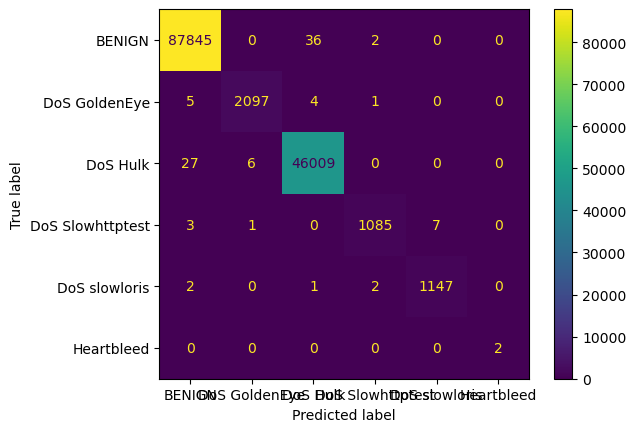

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)